# 13. Визуализация внимания

**Цель:** Извлечь и визуализировать карты внимания из трансформера: per-head heatmaps, паттерны на разных слоях, сравнение self-attention, masked self-attention и cross-attention, attention rollout.

---

In [1]:
# Хуки для извлечения внимания: register_forward_hook перехватывает промежуточные выходы, не изменяя модель
import sys, os, logging, math
LOG_LEVEL = os.getenv("LOG_LEVEL", "DEBUG")
logging.basicConfig(level=getattr(logging, LOG_LEVEL), format="%(asctime)s [%(levelname)s] %(name)s: %(message)s", stream=sys.stderr)
log = logging.getLogger("attn_viz")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Используем устройство: %s", device)

2026-06-01 00:42:32,193 [DEBUG] matplotlib: matplotlib data path: /Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data


2026-06-01 00:42:32,200 [DEBUG] matplotlib: CONFIGDIR=/Users/demanbudaev/.matplotlib


2026-06-01 00:42:32,205 [DEBUG] matplotlib: interactive is False


2026-06-01 00:42:32,205 [DEBUG] matplotlib: platform is darwin


2026-06-01 00:42:32,233 [DEBUG] matplotlib: CACHEDIR=/Users/demanbudaev/.matplotlib


2026-06-01 00:42:32,235 [DEBUG] matplotlib.font_manager: Using fontManager instance from /Users/demanbudaev/.matplotlib/fontlist-v390.json


2026-06-01 00:42:32,358 [INFO] attn_viz: Используем устройство: mps


## 13.1 Модель с хуками для извлечения attention weights

Используем register_forward_hook для перехвата attention из каждого слоя.

In [2]:
# Хуки для извлечения внимания: register_forward_hook перехватывает промежуточные выходы, не изменяя модель
# Паттерны внимания: диагональ (позиционный фокус), вертикальные линии (синтаксические связи), блоки (семантические группы)
log.debug("Building transformer with attention hooks")

class AttentionCapture:
    def __init__(self):
        self.attentions = []
    
    def hook_fn(self, module, input, output):
        # output[1] — веса внимания, если модуль возвращает (output, attn)
        if isinstance(output, tuple):
            self.attentions.append(output[1].detach())

class MultiHeadAttentionWithHook(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.d_k = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.n_heads = n_heads
    
    def forward(self, Q, K, V, mask=None, return_attn=True):
        batch = Q.size(0)
        Q = self.W_Q(Q).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = self.dropout(F.softmax(scores, dim=-1))
        if return_attn:
            output = torch.matmul(attn, V).transpose(1, 2).contiguous().view(batch, -1, self.W_O.out_features)
            return self.W_O(output), attn
        else:
            return self.W_O(torch.matmul(attn, V).transpose(1, 2).contiguous().view(batch, -1, self.W_O.out_features))

class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttentionWithHook(d_model, n_heads, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4*d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(4*d_model, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
    def forward(self, x, mask=None):
        attn_out, attn = self.attention(self.norm1(x), self.norm1(x), self.norm1(x), mask)
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return x, attn

class EncoderWithHooks(nn.Module):
    def __init__(self, vocab_size, d_model=32, n_heads=4, num_layers=4, max_len=50, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
        self.layers = nn.ModuleList([EncoderBlock(d_model, n_heads, dropout) for _ in range(num_layers)])
    
    def forward(self, x, mask=None):
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim) + self.pe[:, :x.size(1), :]
        all_attentions = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            all_attentions.append(attn)
        return x, all_attentions

log.debug("Encoder with attention hooks created")

2026-06-01 00:42:32,369 [DEBUG] attn_viz: Building transformer with attention hooks


2026-06-01 00:42:32,370 [DEBUG] attn_viz: Encoder with attention hooks created


In [3]:
# Хуки для извлечения внимания: register_forward_hook перехватывает промежуточные выходы, не изменяя модель
# Паттерны внимания: диагональ (позиционный фокус), вертикальные линии (синтаксические связи), блоки (семантические группы)
log.debug("Running forward pass to capture attention")

enc = EncoderWithHooks(vocab_size=20, d_model=32, n_heads=4, num_layers=4)
input_ids = torch.randint(3, 20, (1, 12))
output, all_attentions = enc(input_ids)

print(f"Number of layers with attention: {len(all_attentions)}")
print(f"Per-layer attention shape: {all_attentions[0].shape}")
print(f"  (batch, n_heads, seq_len, seq_len)")
log.info("Attention captured from %d layers", len(all_attentions))

2026-06-01 00:42:32,373 [DEBUG] attn_viz: Running forward pass to capture attention


2026-06-01 00:42:32,378 [INFO] attn_viz: Attention captured from 4 layers


Number of layers with attention: 4
Per-layer attention shape: torch.Size([1, 4, 12, 12])
  (batch, n_heads, seq_len, seq_len)


## 13.2 Визуализация: attention head-by-head (heatmaps)

2026-06-01 00:42:32,383 [DEBUG] attn_viz: Plotting per-head attention heatmaps


2026-06-01 00:42:32,386 [DEBUG] matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.


2026-06-01 00:42:32,387 [DEBUG] matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.


2026-06-01 00:42:32,389 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.


2026-06-01 00:42:32,389 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05


...

2026-06-01 00:42:33,157 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansBuhid-Regular.ttf', name='Noto Sans Buhid', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:42:33,158 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Phosphate.ttc', name='Phosphate', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:42:33,158 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansInscriptionalParthian-Regular.ttf', name='Noto Sans Inscriptional Parthian', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:42:33,158 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/STIXNonUni.otf', name='STIXNonUnicode', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:42:33,158 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=14.0 to DejaVu Sans ('/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf') with score of 0.050000.


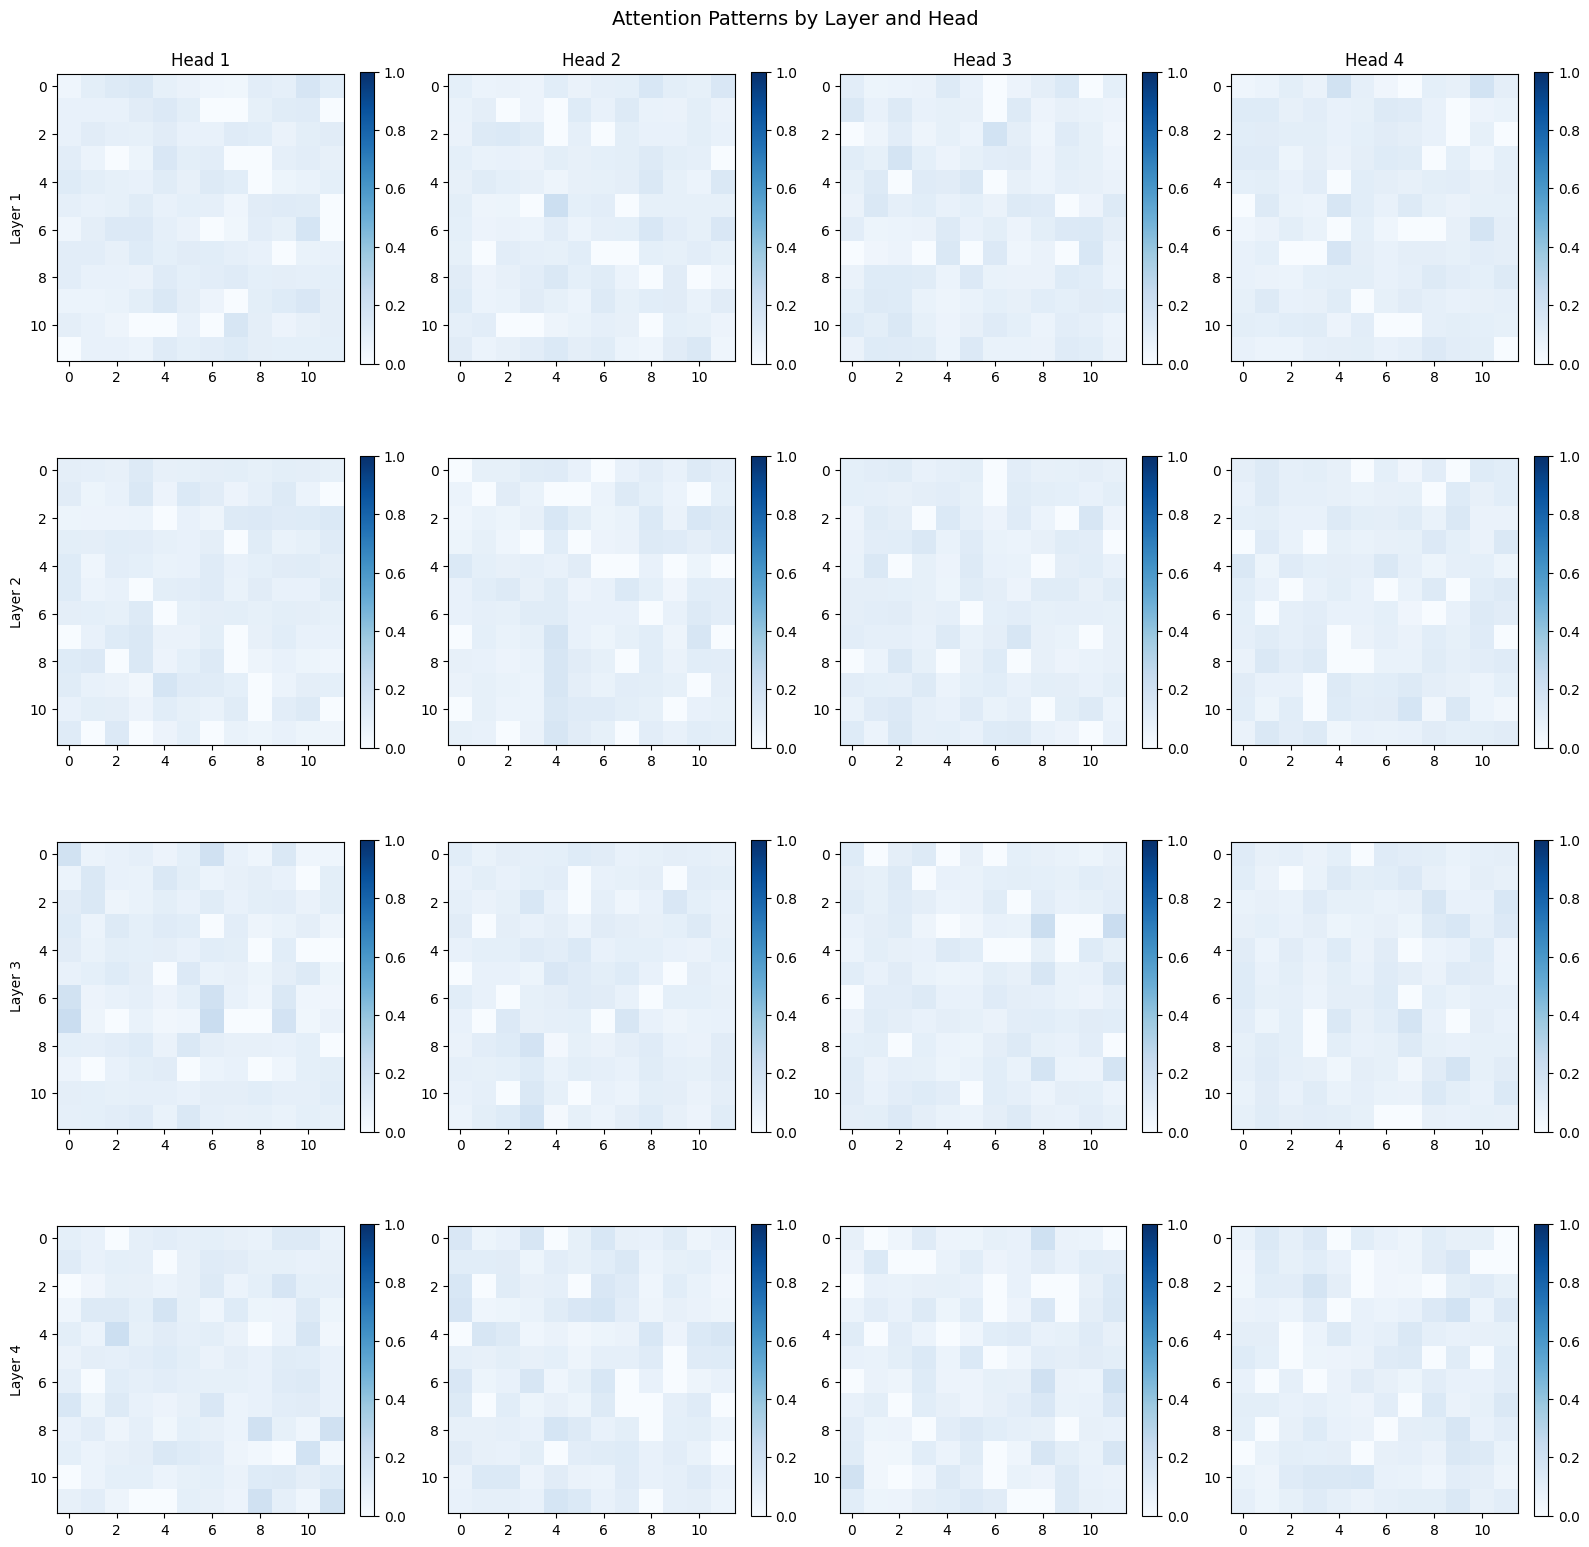

2026-06-01 00:42:33,778 [INFO] attn_viz: Per-head attention heatmaps plotted


In [4]:
# Паттерны внимания: диагональ (позиционный фокус), вертикальные линии (синтаксические связи), блоки (семантические группы)
log.debug("Plotting per-head attention heatmaps")

n_layers = len(all_attentions)
n_heads = all_attentions[0].size(1)

fig, axes = plt.subplots(n_layers, n_heads, figsize=(4*n_heads, 4*n_layers))
for layer_idx in range(n_layers):
    for head_idx in range(n_heads):
        ax = axes[layer_idx, head_idx]
        im = ax.imshow(all_attentions[layer_idx][0, head_idx].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
        if layer_idx == 0:
            ax.set_title(f'Head {head_idx+1}')
        if head_idx == 0:
            ax.set_ylabel(f'Layer {layer_idx+1}')
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Attention Patterns by Layer and Head', fontsize=14)
plt.tight_layout()
plt.show()
log.info("Per-head attention heatmaps plotted")

## 13.3 Анализ паттернов: разные слои

Нижние слои → локальное внимание (соседние токены)
Средние слои → синтаксические паттерны
Верхние слои → семантические, далёкие зависимости

2026-06-01 00:42:33,784 [DEBUG] attn_viz: Analyzing attention patterns across layers


2026-06-01 00:42:33,845 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x111f42970>


2026-06-01 00:42:33,851 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x112c46af0>


2026-06-01 00:42:33,857 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x112d6e640>


2026-06-01 00:42:33,863 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x112db8400>


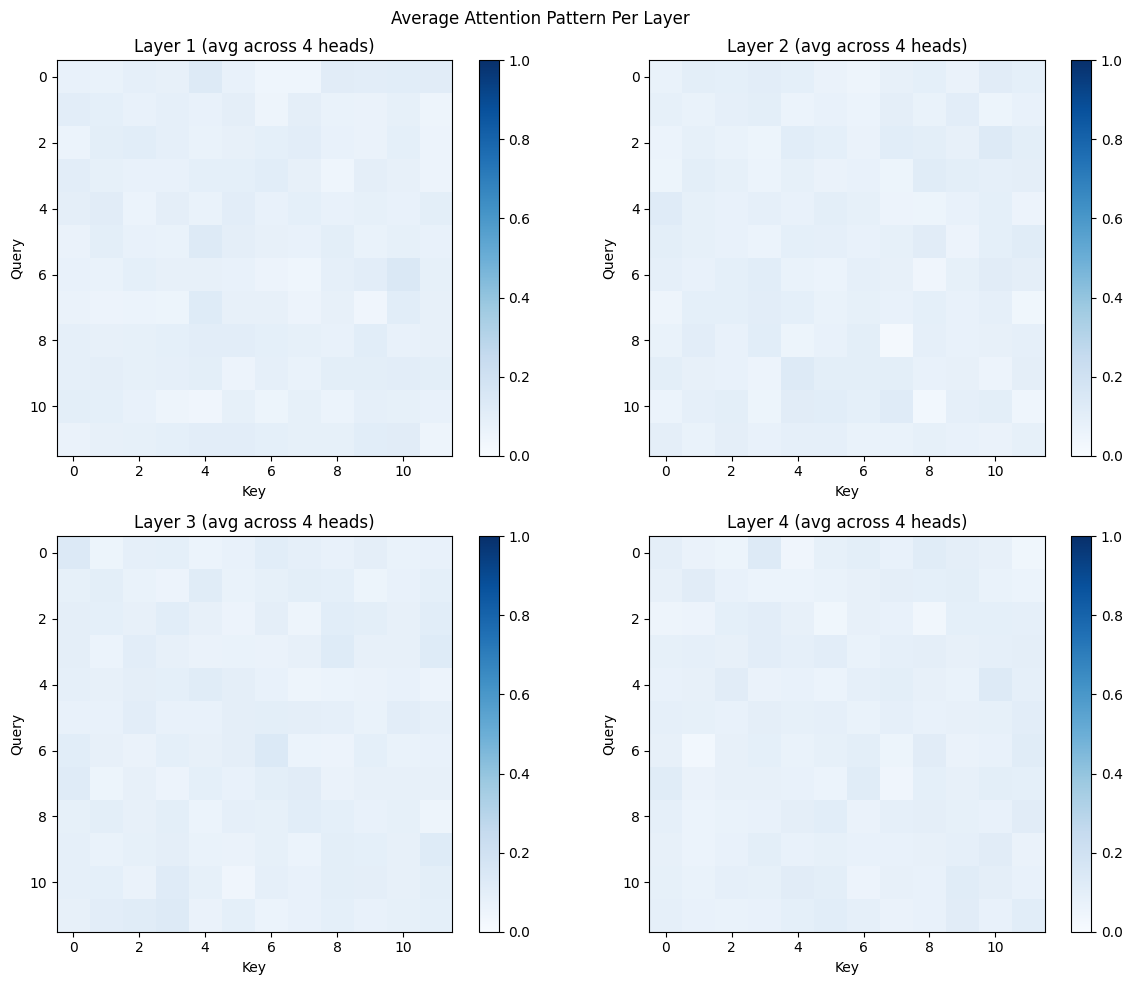

2026-06-01 00:42:34,095 [INFO] attn_viz: Layer analysis complete


In [5]:
# Паттерны внимания: диагональ (позиционный фокус), вертикальные линии (синтаксические связи), блоки (семантические группы)
log.debug("Analyzing attention patterns across layers")

# Среднее по головам для каждого слоя
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, ax in enumerate(axes.flat):
    if i < n_layers:
        avg_attn = all_attentions[i][0].mean(dim=0).detach().numpy()  # среднее по головам
        im = ax.imshow(avg_attn, cmap='Blues', vmin=0, vmax=1)
        ax.set_title(f'Layer {i+1} (avg across {n_heads} heads)')
        ax.set_xlabel('Key')
        ax.set_ylabel('Query')
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Average Attention Pattern Per Layer')
plt.tight_layout()
plt.show()
log.info("Layer analysis complete")

### Attention Rollout: как агрегировать внимание через слои

Внимание на одном слое показывает только **один шаг** взаимодействия токенов —
как каждый токен на этом слое смотрит на другие токены **непосредственно**.
Но в глубинной сети информация проходит через несколько слоёв,
и прямое внимание на слое $L$ не учитывает, как распределяется внимание на слоях $L-1, L-2, \dots$.

**Attention Rollout** решает эту проблему: он последовательно перемножает
матрицы внимания всех слоёв (с добавлением residual-связи как единичной матрицы),
получая **эффективную** карту влияния — какой вклад каждый токен на входе
вносит в каждый токен на выходе всей сети.

Формально: $\tilde{A}^{(i)} = A^{(i)} + I$,
$\text{Rollout} = \tilde{A}^{(1)} \cdot \tilde{A}^{(2)} \cdot \ldots \cdot \tilde{A}^{(L)}$,
где $A^{(i)}$ — усреднённая по головам матрица внимания $i$-го слоя.



## 13.4 Attention Rollout

Агрегируем внимание через все слои, получая "полную" карту влияния токенов друг на друга (Abnar & Zuidema, 2020).

2026-06-01 00:42:34,100 [DEBUG] attn_viz: Computing attention rollout


2026-06-01 00:42:34,111 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x112f42fd0>


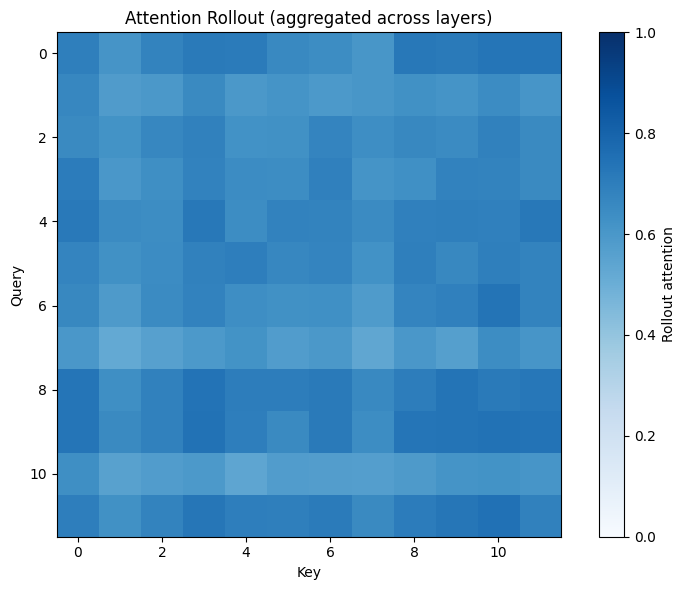

2026-06-01 00:42:34,177 [INFO] attn_viz: Attention rollout computed


In [6]:
# Attention Rollout: агрегация внимания через слои с помощью перемножения матриц внимания
log.debug("Computing attention rollout")

def attention_rollout(attentions, add_residual=True):
    """
    Attention Rollout: агрегирует внимание через все слои.
    
    Args:
        attentions: список тензоров (batch, n_heads, seq_len, seq_len)
        add_residual: добавлять identity matrix (остаточные связи)
    """
    # Среднее по головам
    avg_attn = [attn.mean(dim=1) for attn in attentions]  # список (batch, seq_len, seq_len)
    
    rollout = avg_attn[0]
    for i in range(1, len(avg_attn)):
        if add_residual:
            rollout = rollout @ (avg_attn[i] + torch.eye(avg_attn[i].size(-1)))
        else:
            rollout = rollout @ avg_attn[i]
    
    return rollout  # (batch, seq_len, seq_len)

rollout = attention_rollout(all_attentions)

plt.figure(figsize=(8, 6))
plt.imshow(rollout[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='Rollout attention')
plt.title('Attention Rollout (aggregated across layers)')
plt.xlabel('Key')
plt.ylabel('Query')
plt.tight_layout()
plt.show()
log.info("Attention rollout computed")

## 13.5 Сравнение Self-Attention, Masked Self-Attention, Cross-Attention

Визуализируем разницу между типами внимания на простом примере.

2026-06-01 00:42:34,182 [DEBUG] attn_viz: Comparing attention types


2026-06-01 00:42:34,202 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x113089fd0>


2026-06-01 00:42:34,208 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x1130d3be0>


2026-06-01 00:42:34,214 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x11311e610>


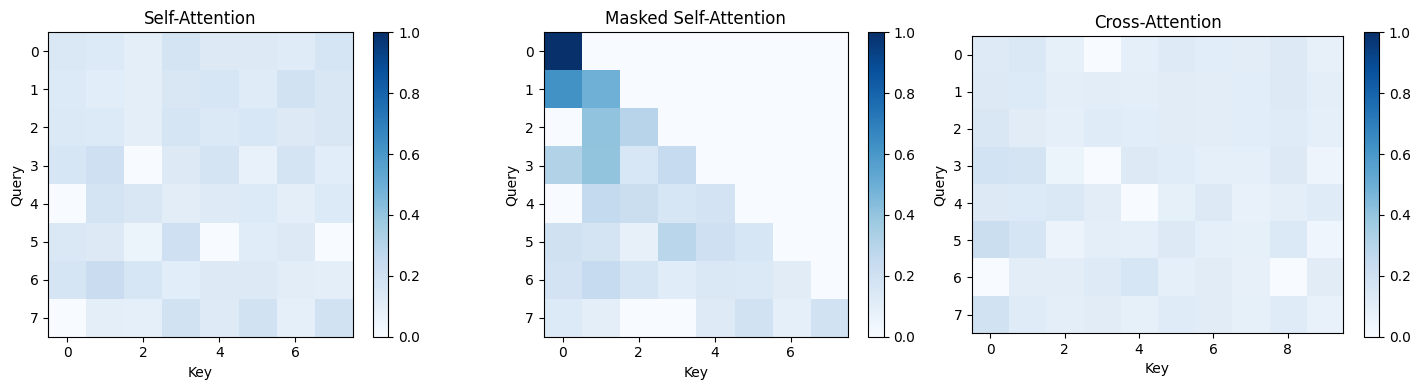

2026-06-01 00:42:34,382 [INFO] attn_viz: Attention type comparison complete


In [7]:
# Хуки для извлечения внимания: register_forward_hook перехватывает промежуточные выходы, не изменяя модель
# Паттерны внимания: диагональ (позиционный фокус), вертикальные линии (синтаксические связи), блоки (семантические группы)
log.debug("Comparing attention types")

mha = MultiHeadAttentionWithHook(d_model=16, n_heads=2)

# Self-attention (двунаправленное)
x = torch.randn(1, 8, 16)
out_sa, attn_sa = mha(x, x, x)

# Masked self-attention (причинное)
seq_len = 8
causal = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
out_msa, attn_msa = mha(x, x, x, mask=~causal)

# Cross-attention (перекрёстное внимание) (Q != K, V)
enc_out = torch.randn(1, 10, 16)
out_ca, attn_ca = mha(x, enc_out, enc_out)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
types = [
    ('Self-Attention', attn_sa),
    ('Masked Self-Attention', attn_msa),
    ('Cross-Attention', attn_ca),
]
for ax, (name, attn) in zip(axes, types):
    im = ax.imshow(attn[0, 0].detach().detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(name)
    ax.set_xlabel('Key')
    ax.set_ylabel('Query')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
log.info("Attention type comparison complete")

In [8]:
# Паттерны внимания: диагональ (позиционный фокус), вертикальные линии (синтаксические связи), блоки (семантические группы)
print("=== Attention Visualization complete ===")
print("Topics covered:")
print("  - Attention hooks for weight capture")
print("  - Per-layer, per-head heatmaps")
print("  - Average attention across heads")
print("  - Attention Rollout aggregation")
print("  - Self-Attention vs Masked vs Cross-Attention")
print("  - Layer-wise pattern analysis")
log.info("Attention visualization notebook complete")

2026-06-01 00:42:34,385 [INFO] attn_viz: Attention visualization notebook complete


=== Attention Visualization complete ===
Topics covered:
  - Attention hooks for weight capture
  - Per-layer, per-head heatmaps
  - Average attention across heads
  - Attention Rollout aggregation
  - Self-Attention vs Masked vs Cross-Attention
  - Layer-wise pattern analysis


---
## References

- Abnar, S., & Zuidema, W. (2020). *Quantifying Attention Flow in Transformers.*
  ACL 2020. https://aclanthology.org/2020.acl-main.385/
